# Exploration des événements et de leur impact sur les ventes par magasin

Dans le notebook précédent, nous avons analysé les disparités de volume et de comportement entre les 10 magasins. Nous avons notamment observé que les trois états suivent la même dynamique temporelle avec des pics et creux simultanés, ce qui suggère que certains facteurs externes communs influencent la demande.

Ce notebook a pour objectif d'identifier et de quantifier ces facteurs. On commence par analyser la saisonnalité mensuelle pour déterminer si les mois expliquent les variations de ventes, puis on se concentre sur les événements ponctuels du calendrier américain et leur impact sur les ventes, d'abord de façon globale puis magasin par magasin.

Ces observations alimenteront directement notre partie Recherche Opérationnelle en fournissant des règles pour l'optimisation des stocks (contraintes etc) de Sophie Martin. 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


sales    = pd.read_csv('/Users/maelys_thr/Desktop/sales_train_evaluation.csv')
calendar = pd.read_csv('/Users/maelys_thr/Desktop/calendar.csv')

calendar["date"] = pd.to_datetime(calendar["date"])
day_cols         = [c for c in sales.columns if c.startswith('d_')]
day_to_date      = dict(zip(calendar['d'], calendar['date']))

print(f"Période : {calendar['date'].min().date()} - {calendar['date'].max().date()}")
print(f"Nombre d'événements : {calendar['event_name_1'].dropna().nunique()}")
print(f"Événements disponibles : {sorted(calendar['event_name_1'].dropna().unique())}")

Période : 2011-01-29 - 2016-06-19
Nombre d'événements : 30
Événements disponibles : ['Chanukah End', 'Christmas', 'Cinco De Mayo', 'ColumbusDay', 'Easter', 'Eid al-Fitr', 'EidAlAdha', "Father's day", 'Halloween', 'IndependenceDay', 'LaborDay', 'LentStart', 'LentWeek2', 'MartinLutherKingDay', 'MemorialDay', "Mother's day", 'NBAFinalsEnd', 'NBAFinalsStart', 'NewYear', 'OrthodoxChristmas', 'OrthodoxEaster', 'Pesach End', 'PresidentsDay', 'Purim End', 'Ramadan starts', 'StPatricksDay', 'SuperBowl', 'Thanksgiving', 'ValentinesDay', 'VeteransDay']


## 1. Saisonnalité mensuelle des ventes

Avant d'analyser les événements ponctuels, on vérifie d'abord si les mois de l'année influencent les ventes au sein des 10 magasins. Si la saisonnalité mensuelle est faible, cela confirmera que ce sont les événements ponctuels qui créent les vraies variations. On procède par une analyse certes approfondie et détaillée (qui m'a parfois moi-même perdue) mais qui nous permet de comprendre les limites et de réflechir correctement au fur et à mesure. 

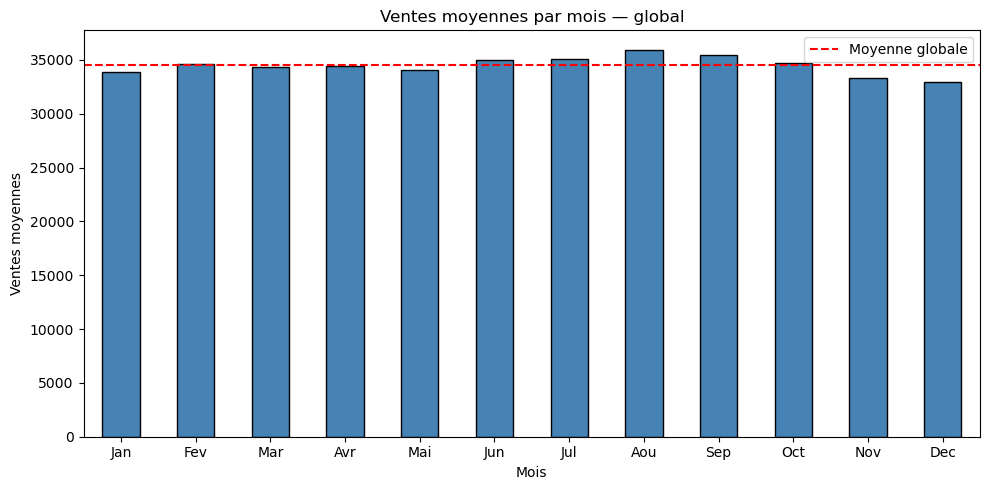

Mois le plus fort : Aou
Mois le plus faible : Dec


In [5]:
mois_labels = ["Jan", "Fev", "Mar", "Avr", "Mai", "Jun",
               "Jul", "Aou", "Sep", "Oct", "Nov", "Dec"]

total_daily = pd.Series(
    sales[day_cols].sum().values,
    index=[day_to_date[d] for d in day_cols]
).sort_index()

baseline = total_daily.mean()

ventes_par_mois = total_daily.groupby(total_daily.index.month).mean()
ventes_par_mois.index = mois_labels

ventes_par_mois.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(10, 5))
plt.title("Ventes moyennes par mois — global")
plt.xlabel("Mois")
plt.ylabel("Ventes moyennes")
plt.axhline(baseline, color="red", linestyle="--", label="Moyenne globale")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("Mois le plus fort :", mois_labels[ventes_par_mois.argmax()])
print("Mois le plus faible :", mois_labels[ventes_par_mois.argmin()])

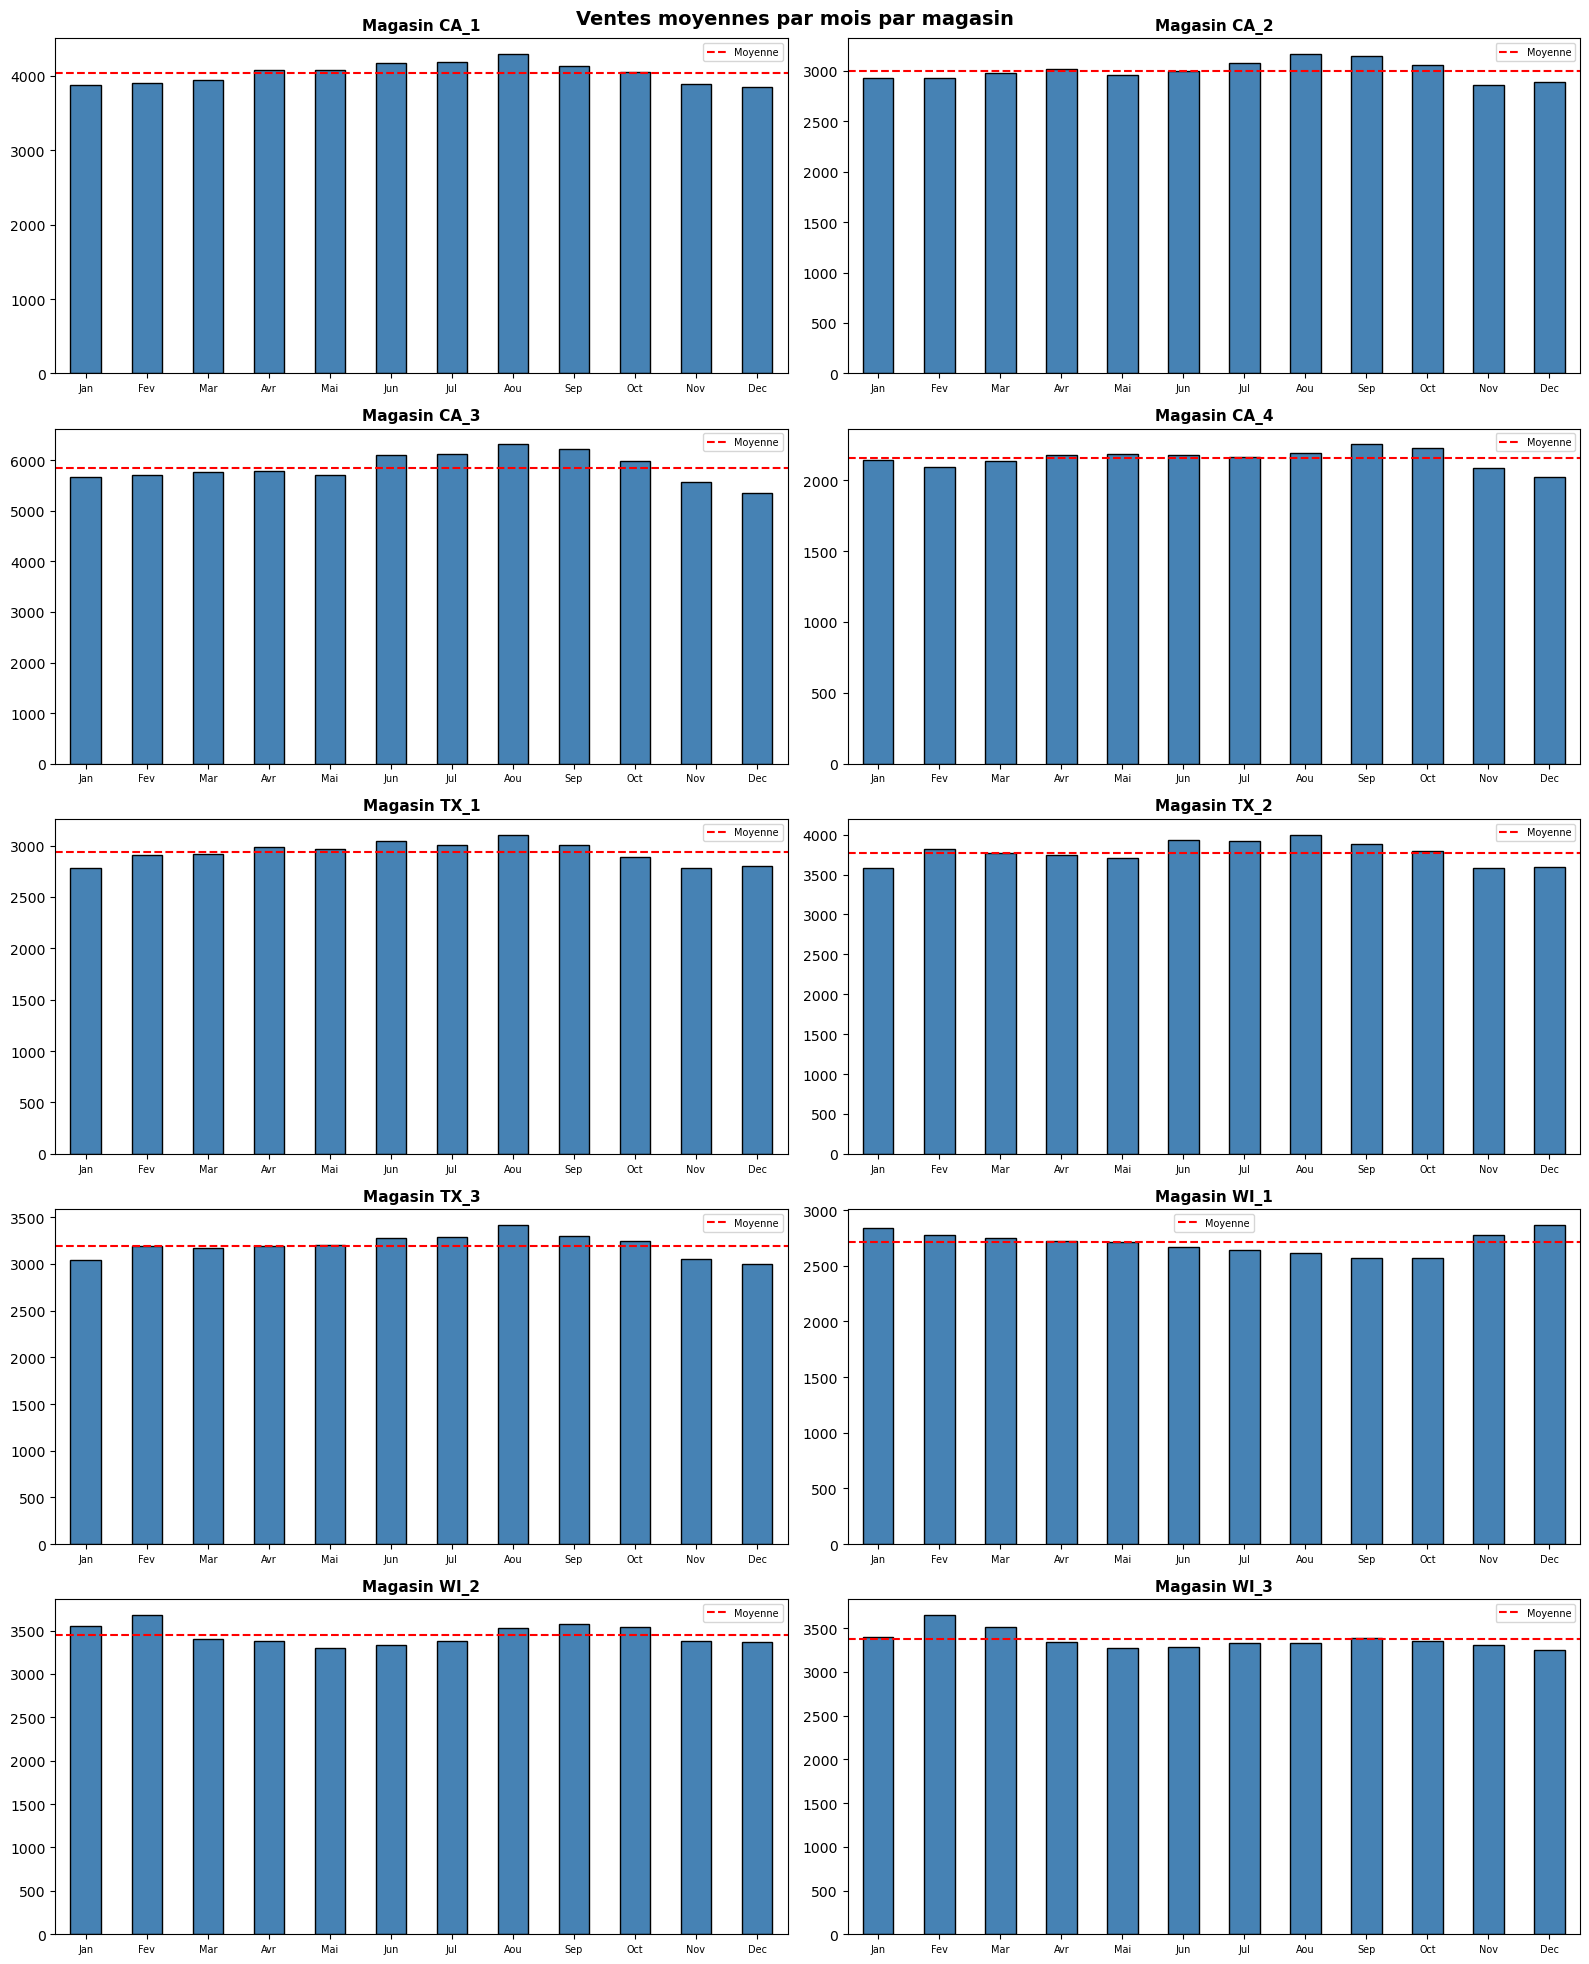

In [23]:
# Ventes moyennes par mois pour chaque magasin
sales_by_store = sales.groupby('store_id')[day_cols].sum()
mois_labels = ["Jan", "Fev", "Mar", "Avr", "Mai", "Jun",
               "Jul", "Aou", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, store in enumerate(sorted(sales_by_store.index)):
    store_daily = pd.Series( # Série temporelle des ventes journalières du magasin
        sales_by_store.loc[store].values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()
    
    ventes_mois = store_daily.groupby(store_daily.index.month).mean() # Moyenne des ventes par mois
    ventes_mois.index = mois_labels  # Remplacement des numéros de mois par leurs noms
    baseline_store = store_daily.mean()
    
    ventes_mois.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].axhline(baseline_store, color="red", linestyle="--", label="Moyenne")
    axes[i].set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=0, labelsize=7)
    axes[i].legend(fontsize=7)

plt.suptitle('Ventes moyennes par mois par magasin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# Calcul de l'écart entre le mois le plus fort et le plus faible
max_mois = ventes_par_mois.max()
min_mois = ventes_par_mois.min()
ecart = (max_mois - min_mois) / min_mois * 100
print(f"Mois le plus fort ({ventes_par_mois.idxmax()}) : {max_mois:.0f} ventes/jour")
print(f"Mois le plus faible ({ventes_par_mois.idxmin()}) : {min_mois:.0f} ventes/jour")
print(f"Écart : {ecart:.1f}%")

Mois le plus fort (Aou) : 35947 ventes/jour
Mois le plus faible (Dec) : 32980 ventes/jour
Écart : 9.0%


**Interprétation** : Les ventes sont très stables d'un mois à l'autre, aussi bien au niveau global que par magasin. Toutes les barres restent proches de la moyenne globale avec des écarts faibles.

Le mois le plus fort est Août et le plus faible est Décembre avec un écart de 9%. On peut donc conclure que la saisonnalité mensuelle est faible, les mois seuls n'expliquent pas les variations de ventes.

## 2. Saisonnalité hebdomadaire des ventes

La saisonnalité mensuelle étant faible, on affine l'analyse en descendant à l'échelle de la semaine. On cherche à savoir si certains jours de la semaine génèrent structurellement plus de ventes que d'autres.

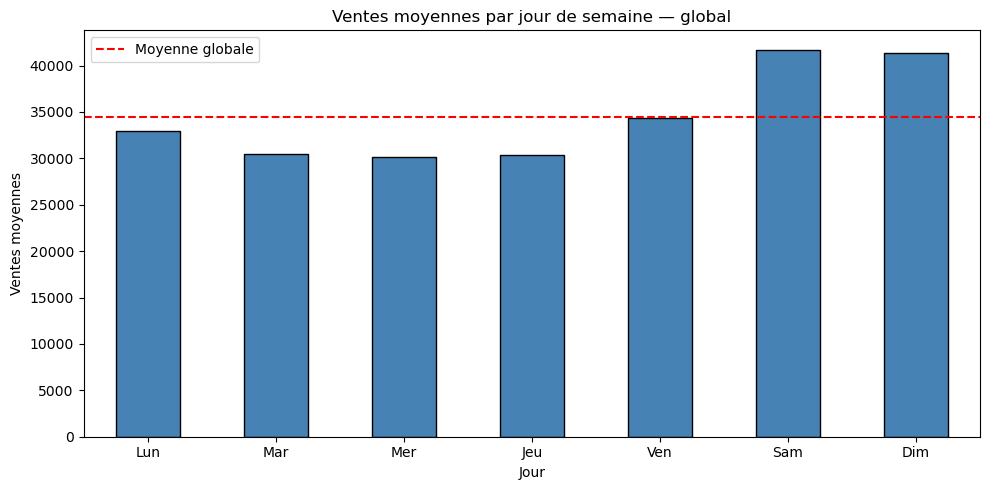

Jour le plus fort : Sam
Jour le plus faible : Mer


In [8]:
ventes_semaine_global = total_daily.groupby(total_daily.index.dayofweek).mean()
ventes_semaine_global.index = jours_labels

ventes_semaine_global.plot(kind="bar", color="steelblue", edgecolor="black", figsize=(10, 5))
plt.title("Ventes moyennes par jour de semaine — global")
plt.xlabel("Jour")
plt.ylabel("Ventes moyennes")
plt.axhline(baseline, color="red", linestyle="--", label="Moyenne globale")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print("Jour le plus fort :", jours_labels[ventes_semaine_global.argmax()])
print("Jour le plus faible :", jours_labels[ventes_semaine_global.argmin()])

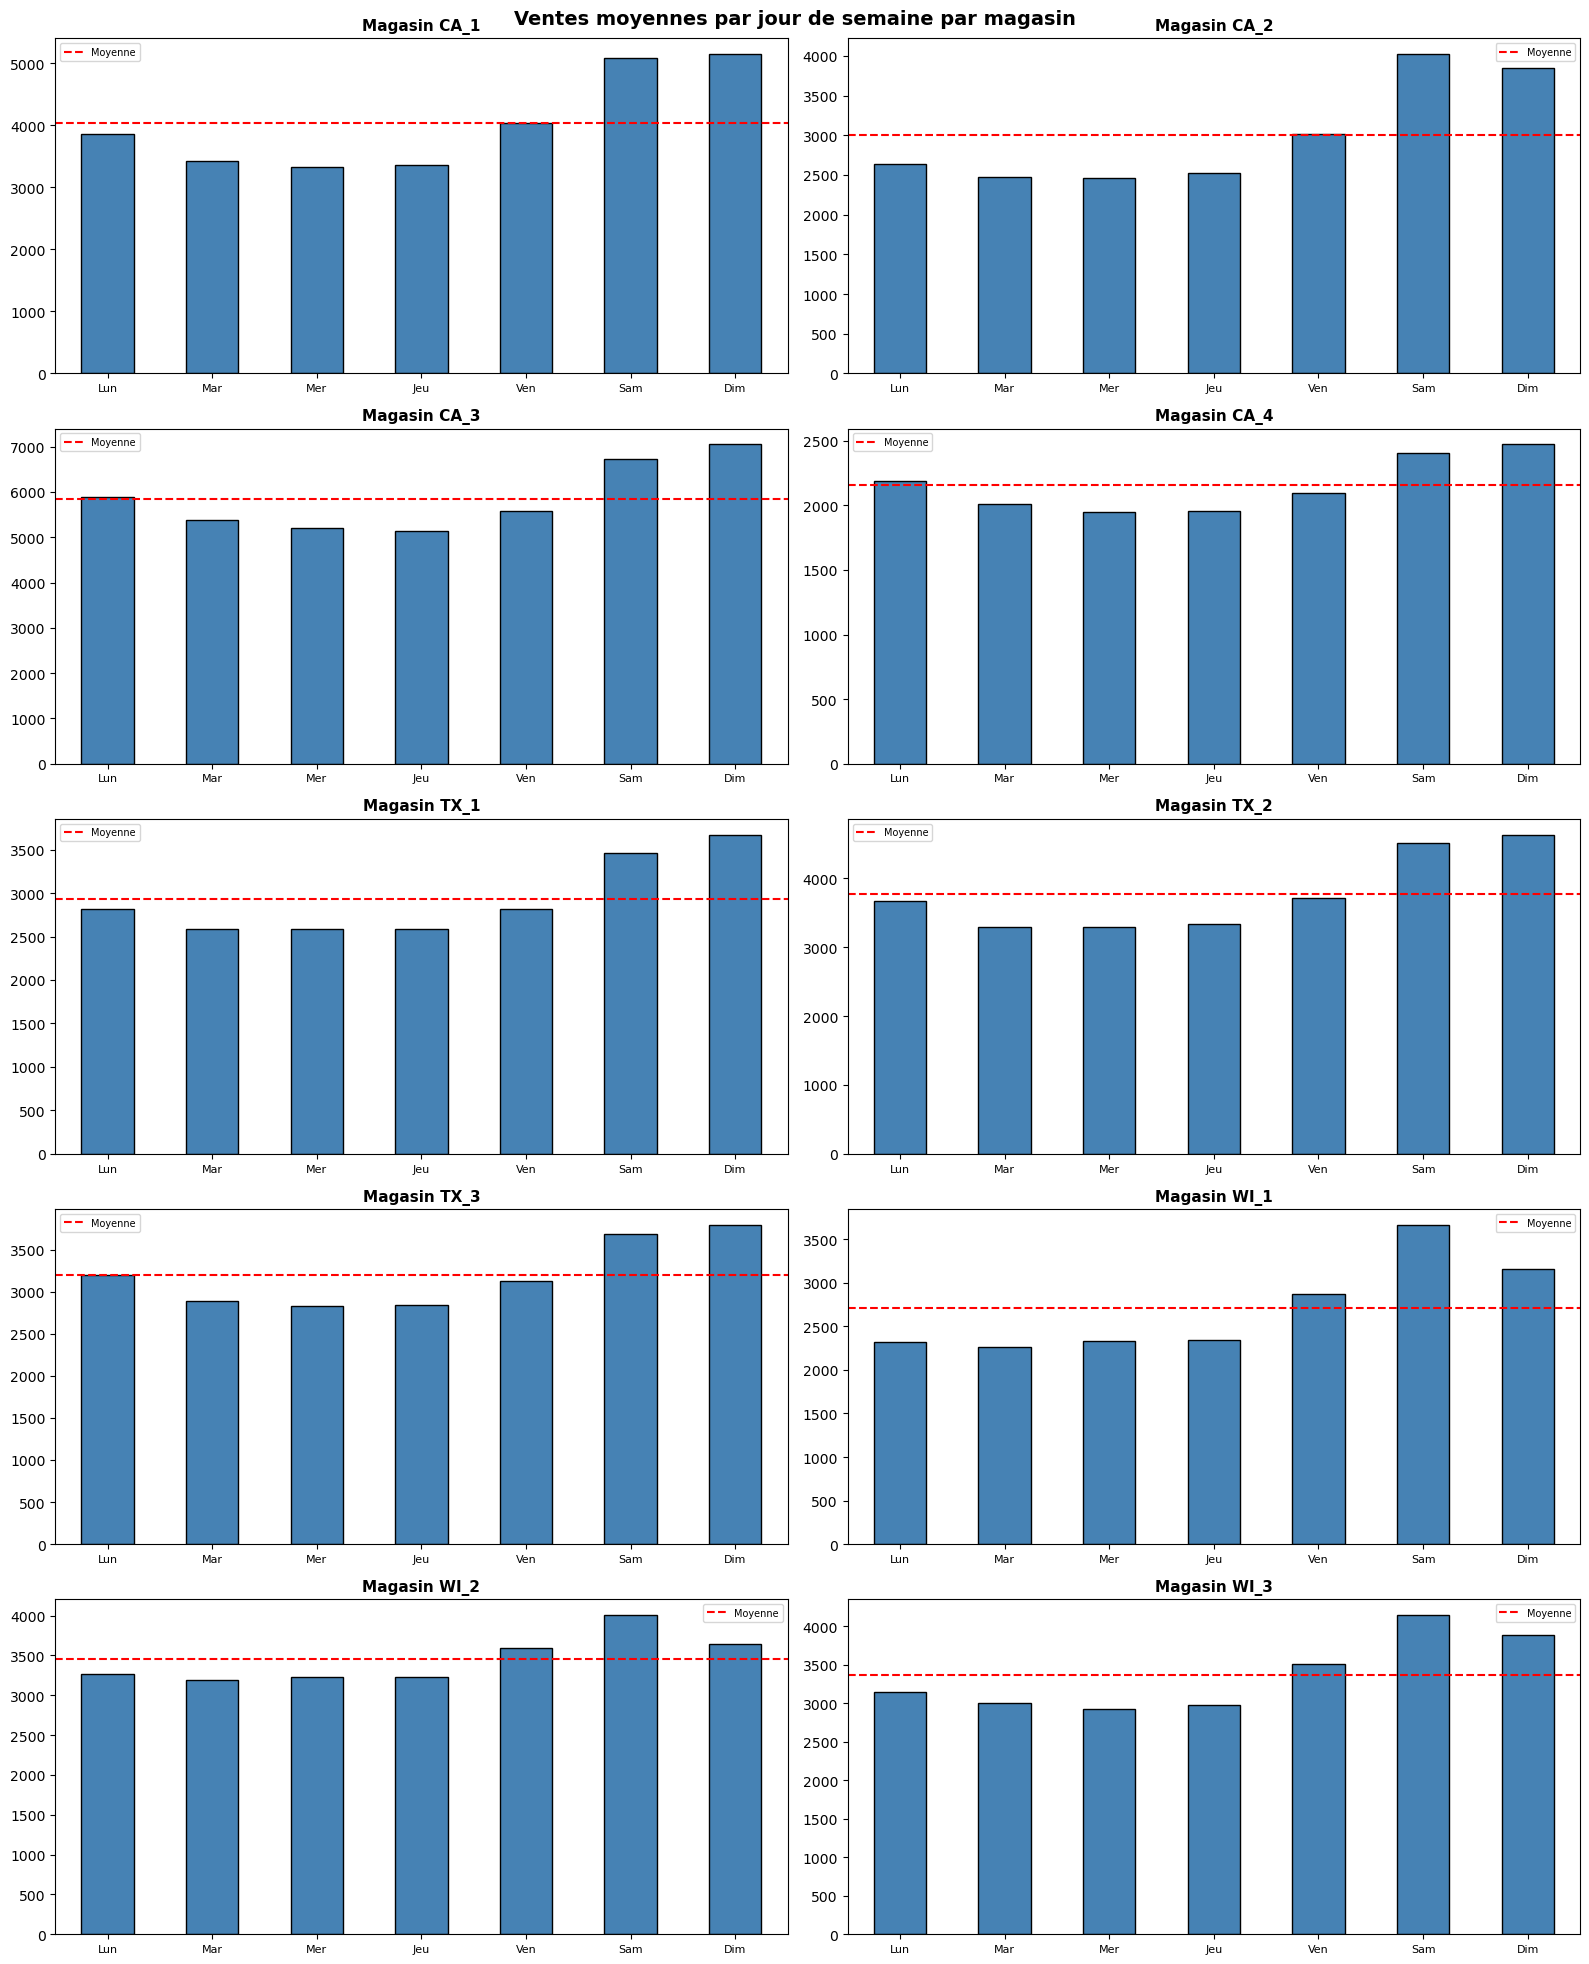

In [7]:
jours_labels = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
sales_by_store = sales.groupby('store_id')[day_cols].sum()

fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for i, store in enumerate(sorted(sales_by_store.index)):
    store_daily = pd.Series(
        sales_by_store.loc[store].values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()
    
    ventes_semaine = store_daily.groupby(store_daily.index.dayofweek).mean()
    ventes_semaine.index = jours_labels
    baseline_store = store_daily.mean()
    
    ventes_semaine.plot(kind="bar", ax=axes[i], color="steelblue", edgecolor="black")
    axes[i].axhline(baseline_store, color="red", linestyle="--", label="Moyenne")
    axes[i].set_title(f'Magasin {store}', fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=0, labelsize=8)
    axes[i].legend(fontsize=7)

plt.suptitle('Ventes moyennes par jour de semaine par magasin', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [11]:
# Calcul de l'écart entre le jour de la semaine le plus fort et le plus faible
max_jour = ventes_semaine_global.max()
min_jour = ventes_semaine_global.min()
ecart = (max_jour - min_jour) / min_jour * 100
print(f"Jour le plus fort ({ventes_semaine_global.idxmax()}) : {max_jour:.0f} ventes/jour")
print(f"Jour le plus faible ({ventes_semaine_global.idxmin()}) : {min_jour:.0f} ventes/jour")
print(f"Écart : {ecart:.1f}%")

Jour le plus fort (Sam) : 41706 ventes/jour
Jour le plus faible (Mer) : 30130 ventes/jour
Écart : 38.4%


**Interprétation** : Contrairement à la saisonnalité mensuelle qui affichait un écart de 9%, la saisonnalité hebdomadaire est forte avec un écart de 38.4% entre le Samedi le jour le plus fort et le Mercredi le plus faible. Ce pattern est identique dans tous les états et tous les magasins sans exception.

Globalement le weekend génère significativement plus de ventes que la semaine. Cette saisonnalité hebdomadaire est une information structurelle importante, elle justifie l'utilisation du jour de semaine comme variable dans notre modèle de prévision, ainsi que l'utilisation de lag_7 pour capturer ce cycle hebdomadaire.

## 3. Analyse des événements du calendrier

Maintenant que nous avons analysé le critère de saisonnalité mensuelle (9%) hebdomadaire (38.4%). On en déduit que ces deux facteurs ne suffisent donc pas à expliquer les pics et creux anormaux observés dans les données lors du précédent notebook. 

On s'intéresse maintenant aux événements ponctuels du calendrier américain comme Thanksgiving, Christmas, SuperBowl, Easter etc. qui pourraient créer des variations exceptionnelles au dessus de la tendance normale.
Cependant, cette analyse en particulier témoigne d'une réflexion encore plus aboutie car certains événements comme Noël ou Thanksgiving nécessitent une fenêtre plus large car les gens anticipent leurs achats plusieurs semaines à l'avance.

Les autres événements ont un impact plus court et ponctuel, une fenêtre de J-7 à J+7 est suffisante comme Easter. Donc, je me suis dans un premier temps renseignée sur les différents events afin de pouvoir les classer, j'ai également pu tester certains codes/ plots afin d'être sûre des éléments que j'avance ici. Cependant, on ne les met pas ici car les notebooks sont déjà assez riches. 
Ce que l'on fait ici va autant nous aider sur la partie event sur la page magasins du streamlit que la partie Recherche opérationnelle. 

In [12]:
# events où les gens anticipent longtemps à l'avance avec une fenêtre J-28 à J+7
events_longs = {
    "Christmas"   : list(range(-28, 8)),
    "Thanksgiving": list(range(-28, 8)),
    "Halloween"   : list(range(-28, 8)),
    "NewYear"     : list(range(-28, 8)),
    "Chanukah End": list(range(-28, 8))
}

# tous les autres events avec une fenêtre J-7 à J+7
events_courts = {
    "SuperBowl"        : list(range(-7, 8)),
    "ValentinesDay"    : list(range(-7, 8)),
    "PresidentsDay"    : list(range(-7, 8)),
    "LentStart"        : list(range(-7, 8)),
    "StPatricksDay"    : list(range(-7, 8)),
    "OrthodoxEaster"   : list(range(-7, 8)),
    "Cinco De Mayo"    : list(range(-7, 8)),
    "Mother's day"     : list(range(-7, 8)),
    "MemorialDay"      : list(range(-7, 8)),
    "NBAFinalsStart"   : list(range(-7, 8)),
    "NBAFinalsEnd"     : list(range(-7, 8)),
    "Father's day"     : list(range(-7, 8)),
    "IndependenceDay"  : list(range(-7, 8)),
    "LaborDay"         : list(range(-7, 8)),
    "ColumbusDay"      : list(range(-7, 8)),
    "VeteransDay"      : list(range(-7, 8)),
    "EidAlAdha"        : list(range(-7, 8)),
    "Eid al-Fitr"      : list(range(-7, 8)),
    "Ramadan starts"   : list(range(-7, 8)),
    "MartinLutherKingDay": list(range(-7, 8)),
    "Easter"           : list(range(-7, 8)),
    "OrthodoxChristmas": list(range(-7, 8)),
    "Purim End"        : list(range(-7, 8)),
    "Pesach End"       : list(range(-7, 8)),
    "LentWeek2"        : list(range(-7, 8))
}

# on fusionne les deux dictionnaires
tous_les_events = {**events_courts, **events_longs}

print(f"Nombre total d events à analyser : {len(tous_les_events)}")
print("Events avec fenêtre longue (J-28) :", list(events_longs.keys()))
print("Events avec fenêtre courte (J-7)  :", list(events_courts.keys()))

Nombre total d events à analyser : 30
Events avec fenêtre longue (J-28) : ['Christmas', 'Thanksgiving', 'Halloween', 'NewYear', 'Chanukah End']
Events avec fenêtre courte (J-7)  : ['SuperBowl', 'ValentinesDay', 'PresidentsDay', 'LentStart', 'StPatricksDay', 'OrthodoxEaster', 'Cinco De Mayo', "Mother's day", 'MemorialDay', 'NBAFinalsStart', 'NBAFinalsEnd', "Father's day", 'IndependenceDay', 'LaborDay', 'ColumbusDay', 'VeteransDay', 'EidAlAdha', 'Eid al-Fitr', 'Ramadan starts', 'MartinLutherKingDay', 'Easter', 'OrthodoxChristmas', 'Purim End', 'Pesach End', 'LentWeek2']


## 3. Analyse des événements du calendrier

### 3.1 Méthodologie

Pour chaque événement on calcule la variation des ventes par rapport à la baseline globale sur une fenêtre temporelle adaptée :

- **Fenêtre longue (J-28 à J+7)** pour les events anticipés longtemps à l'avance : Christmas, Thanksgiving, Halloween, NewYear, Chanukah End
- **Fenêtre courte (J-7 à J+7)** pour tous les autres events ponctuels

Le nombre d'occurrences indique sur combien d'années l'événement a été observé. Plus ce nombre est élevé, plus le résultat est fiable car calculé sur plusieurs années, c'est donc un pattern reproductible et prévisible et l'event pourra potentiellement faire partie de la sélection pour le streamlit. 

### 3.2 Définition de la fonction de calcul d'impact

Pour analyser 30 événements sans répéter le même code 30 fois, on définit une fonction `impact_event` qui retourne la variation des ventes en pourcentage par rapport à la baseline pour chaque jour de la fenêtre.

In [13]:
def impact_event(nom_event, offsets):
    
    # on récupère les dates de l event
    dates = calendar[calendar["event_name_1"] == nom_event]["date"].tolist()
    print(f"{nom_event} : {len(dates)} occurrences")
    
    # pour chaque offset on calcule la variation, l'offset me dit à quel jour correspond chaque variation.
    variations = []
    for offset in offsets:
        ventes = []
        for date in dates:
            date_cible = date + pd.Timedelta(days=offset)
            if date_cible in total_daily.index:
                ventes.append(total_daily[date_cible])
        if ventes:
            variations.append((np.mean(ventes) / baseline - 1) * 100)
        else:
            variations.append(0)
    
    return variations

In [14]:
resultats_globaux = {}
for event, offsets in tous_les_events.items():
    variations = impact_event(event, offsets)
    resultats_globaux[event] = {
        "variations" : variations,
        "offsets"    : offsets
    }

SuperBowl : 6 occurrences
ValentinesDay : 6 occurrences
PresidentsDay : 6 occurrences
LentStart : 6 occurrences
StPatricksDay : 6 occurrences
OrthodoxEaster : 5 occurrences
Cinco De Mayo : 5 occurrences
Mother's day : 6 occurrences
MemorialDay : 6 occurrences
NBAFinalsStart : 6 occurrences
NBAFinalsEnd : 6 occurrences
Father's day : 4 occurrences
IndependenceDay : 5 occurrences
LaborDay : 5 occurrences
ColumbusDay : 5 occurrences
VeteransDay : 5 occurrences
EidAlAdha : 5 occurrences
Eid al-Fitr : 5 occurrences
Ramadan starts : 6 occurrences
MartinLutherKingDay : 5 occurrences
Easter : 5 occurrences
OrthodoxChristmas : 5 occurrences
Purim End : 6 occurrences
Pesach End : 6 occurrences
LentWeek2 : 6 occurrences
Christmas : 5 occurrences
Thanksgiving : 5 occurrences
Halloween : 5 occurrences
NewYear : 5 occurrences
Chanukah End : 5 occurrences


### 3.3 Calcul de l'impact pour tous les événements

On applique la fonction à l'ensemble des événements et on stocke les résultats.

### 3.4 Visualisation de l'impact par événement

Pour chaque événement on visualise la variation des ventes jour par jour autour de la date J. Les barres rouges indiquent une hausse des ventes, les bleues une baisse.

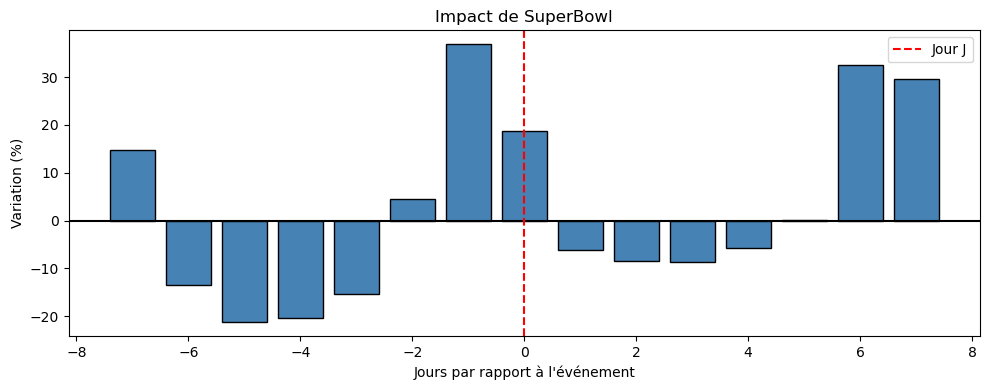

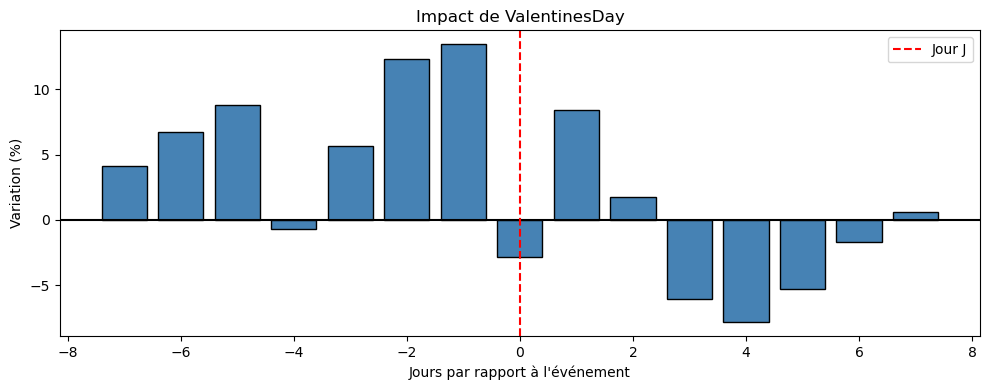

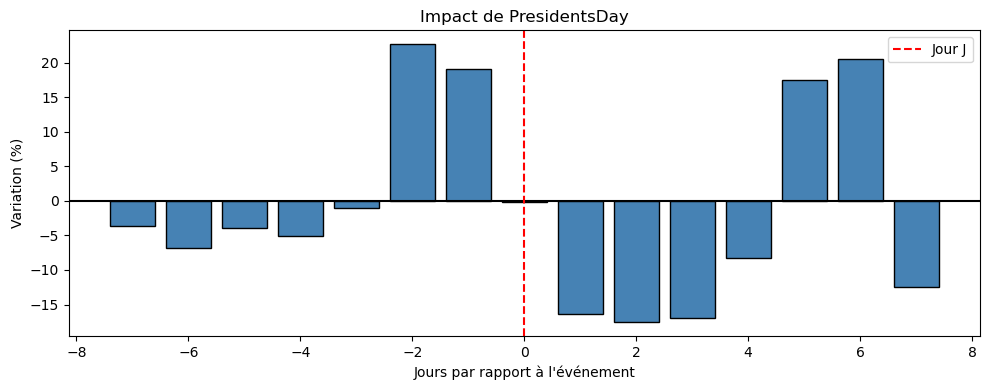

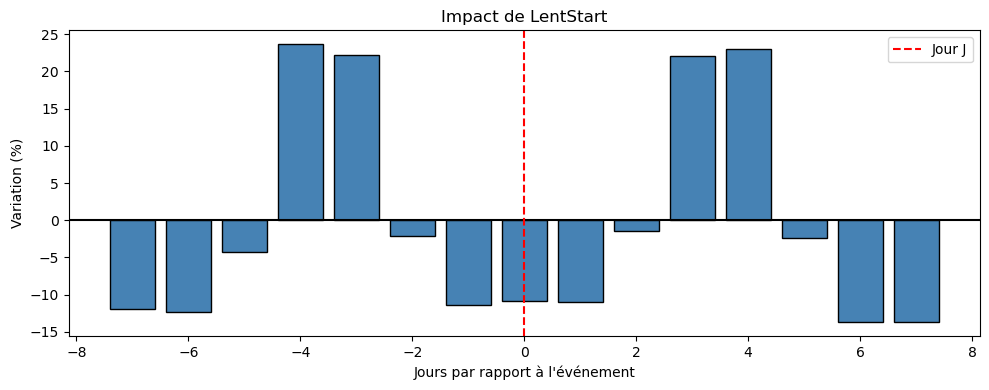

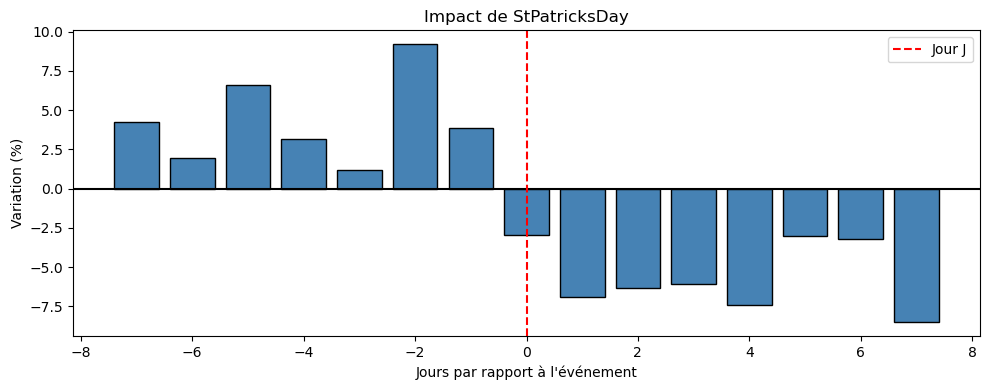

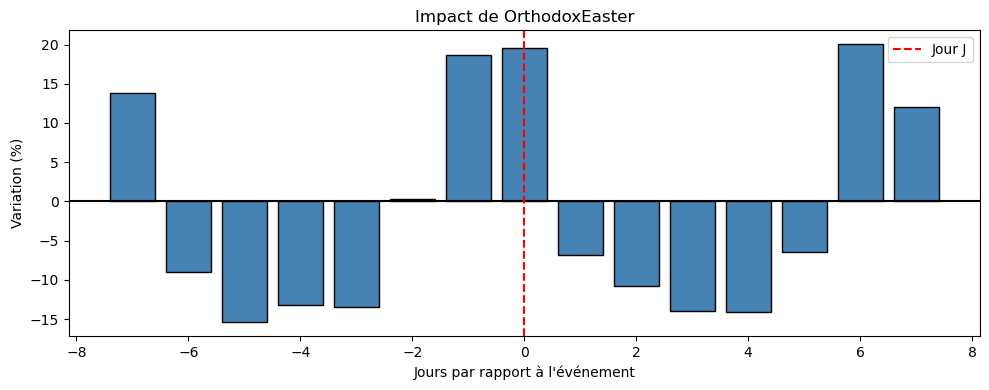

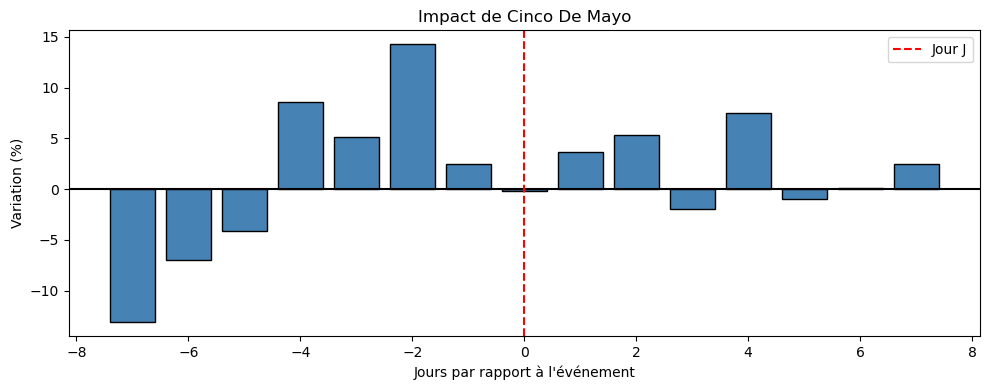

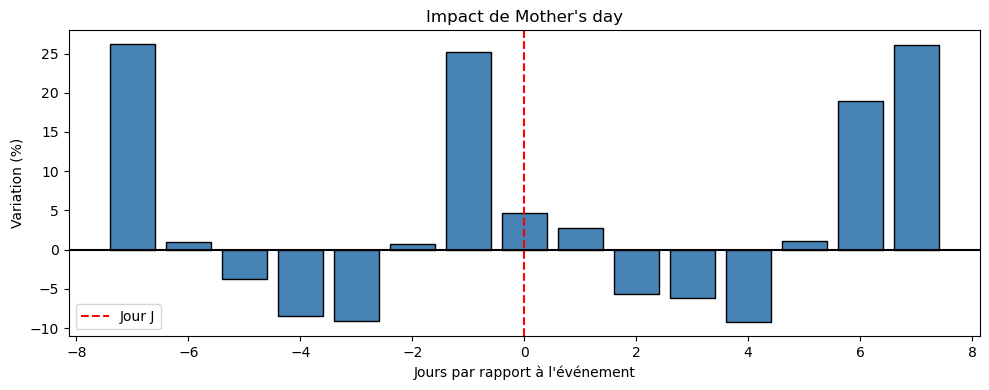

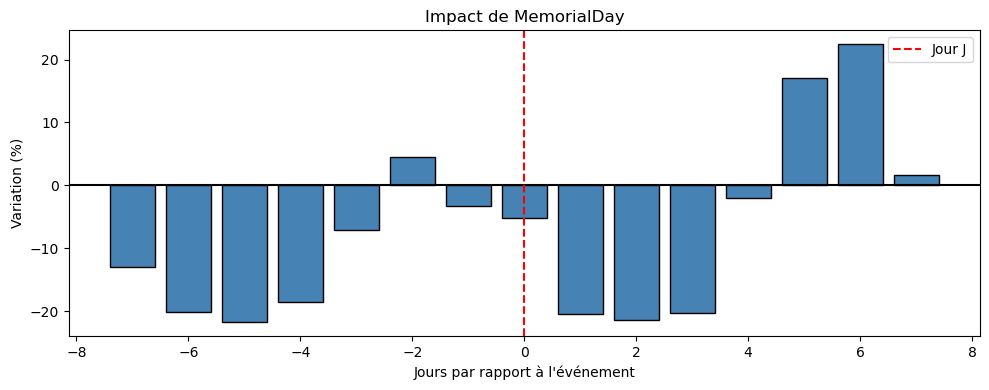

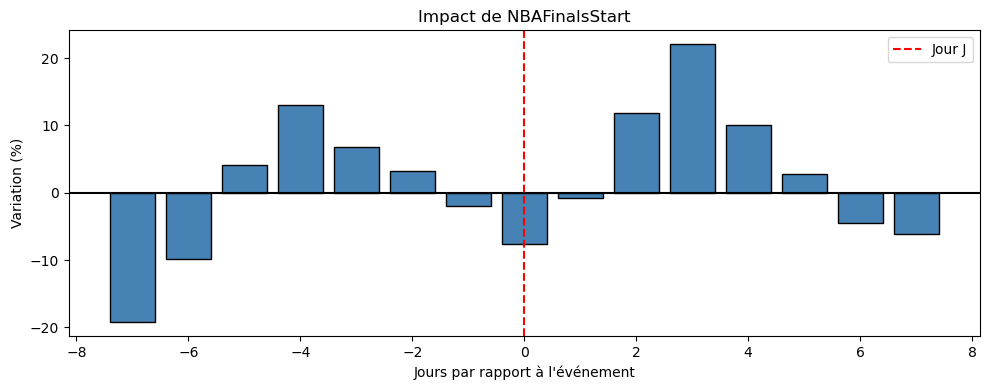

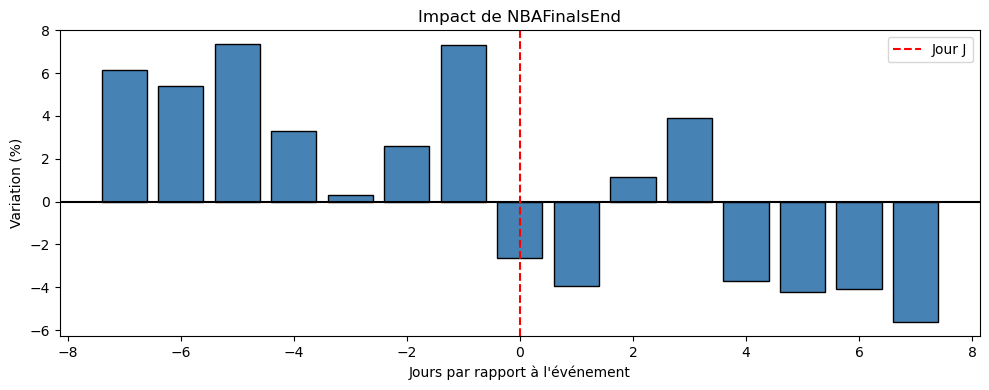

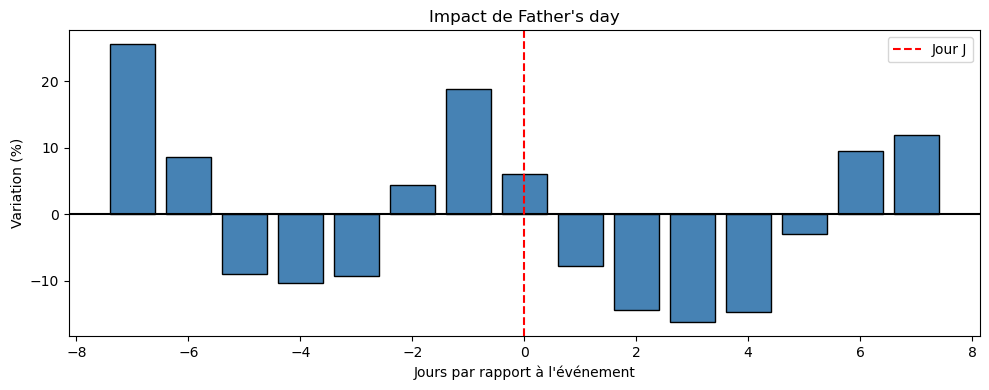

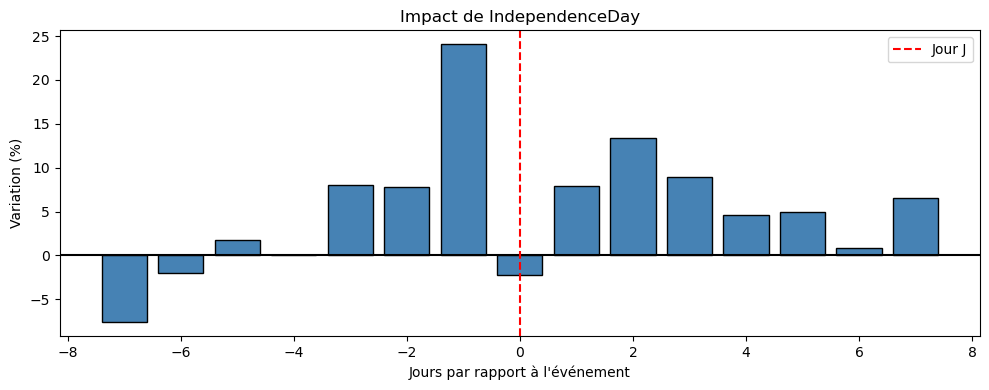

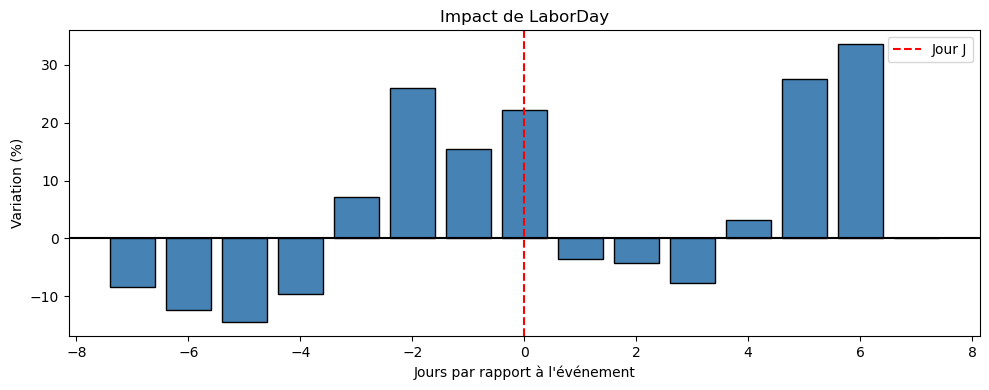

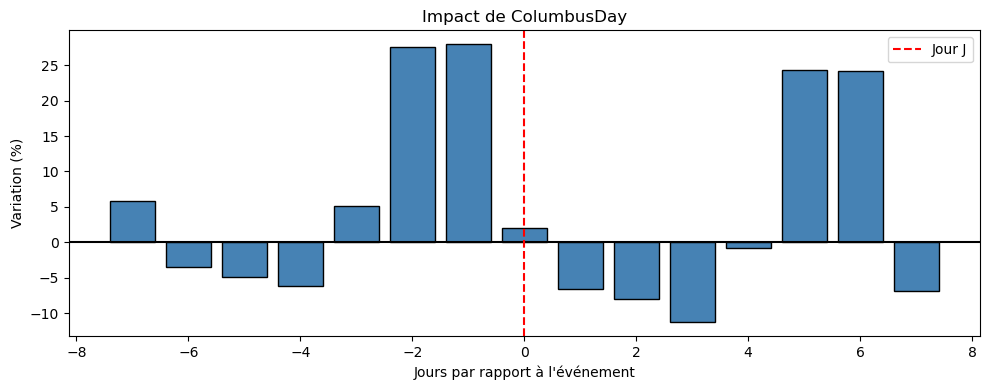

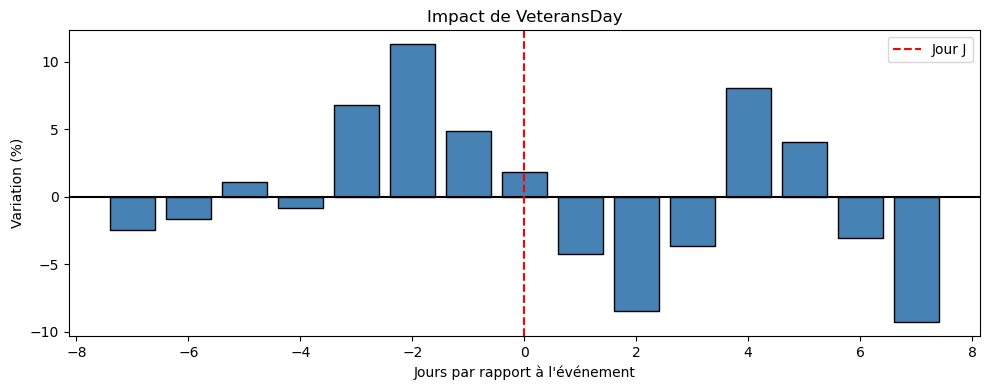

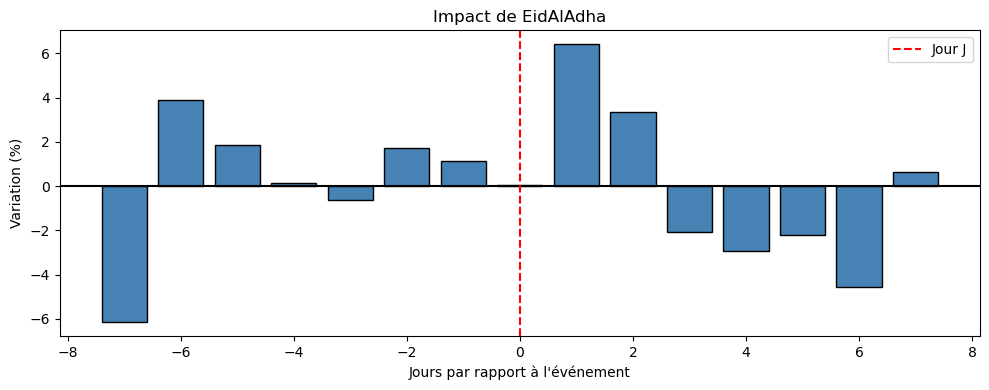

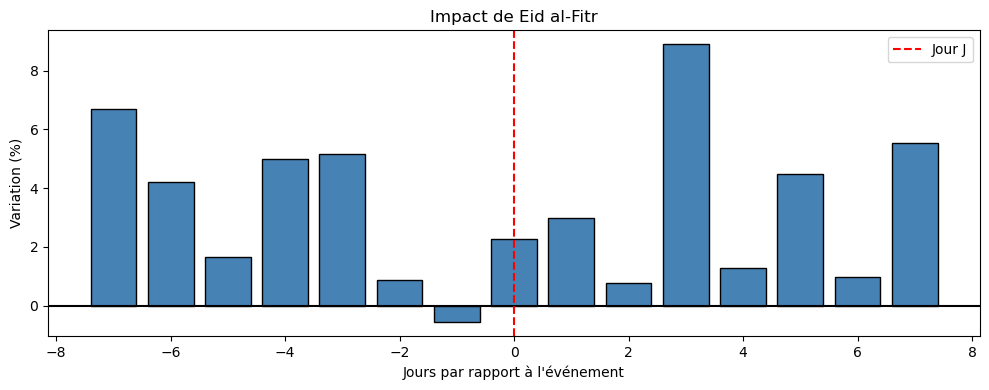

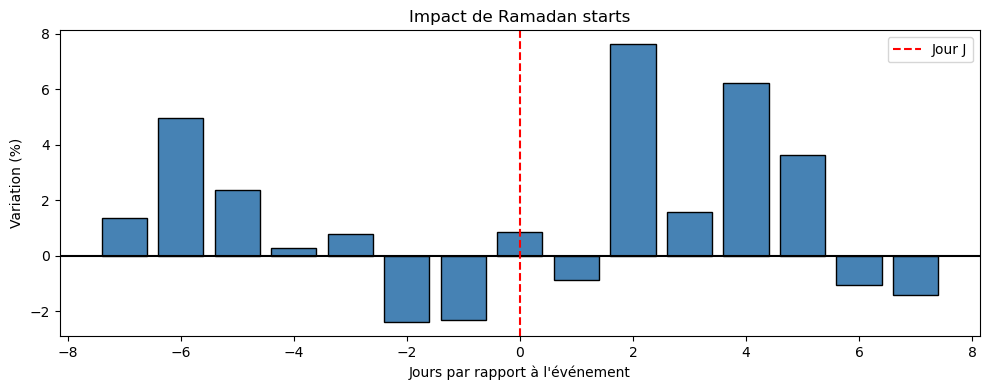

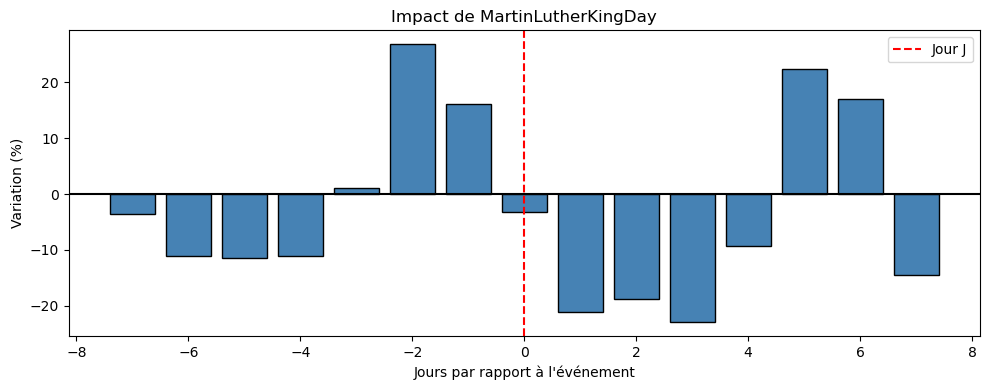

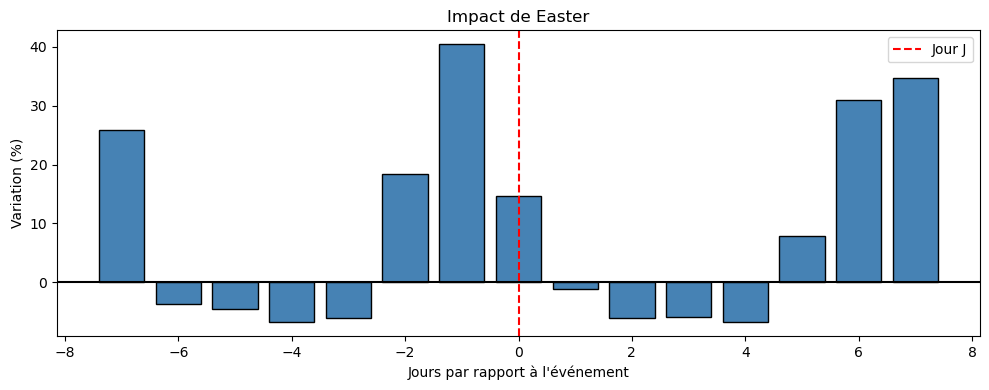

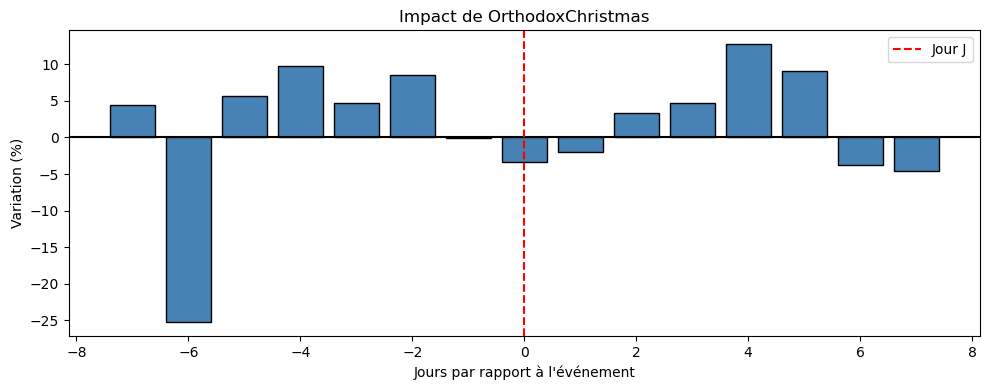

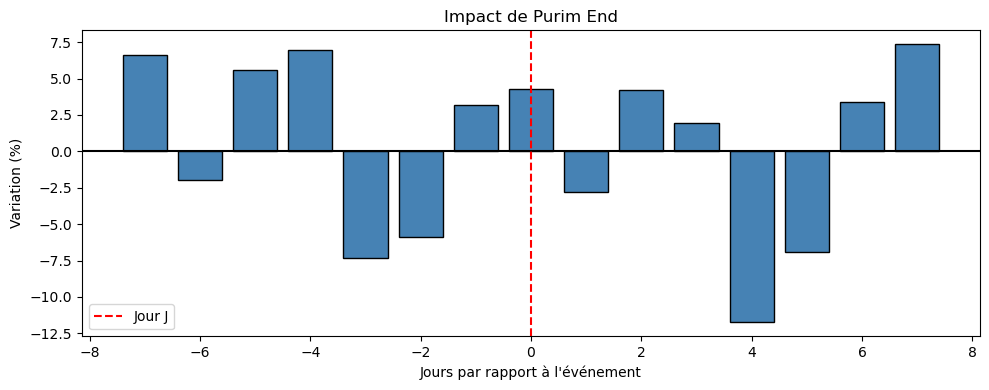

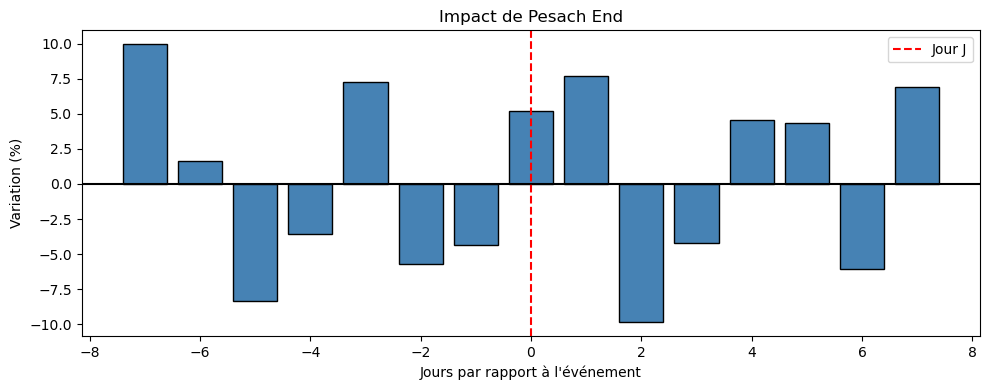

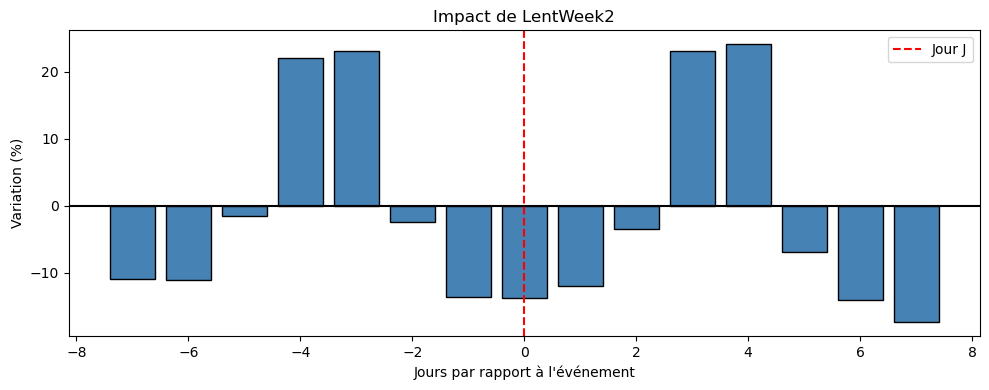

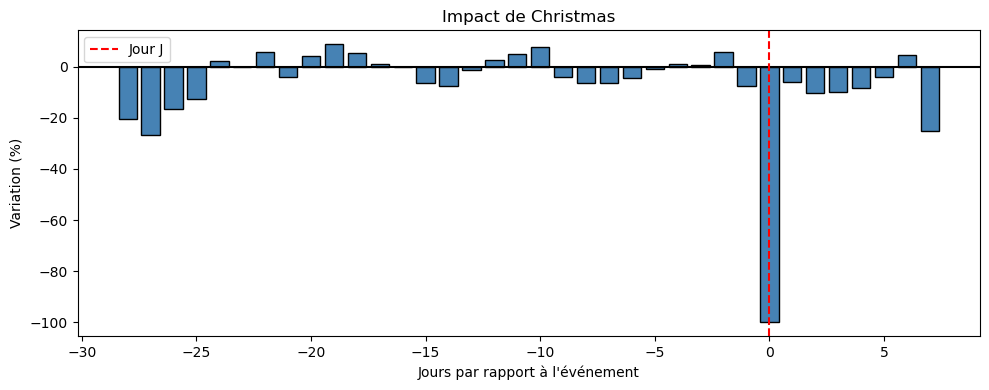

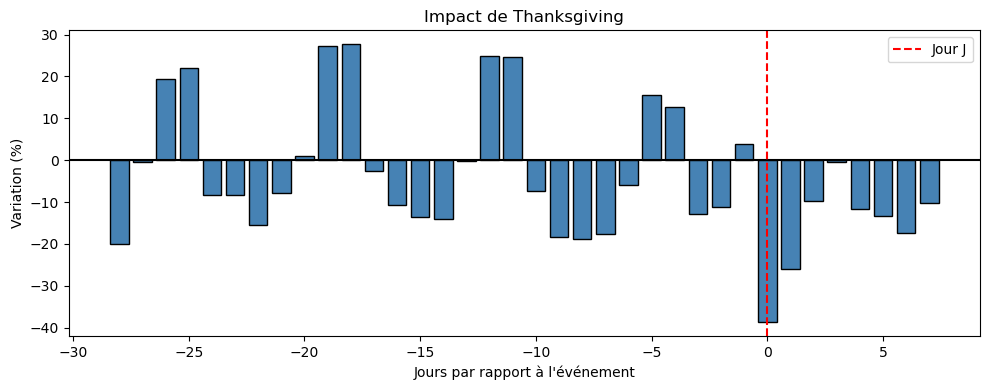

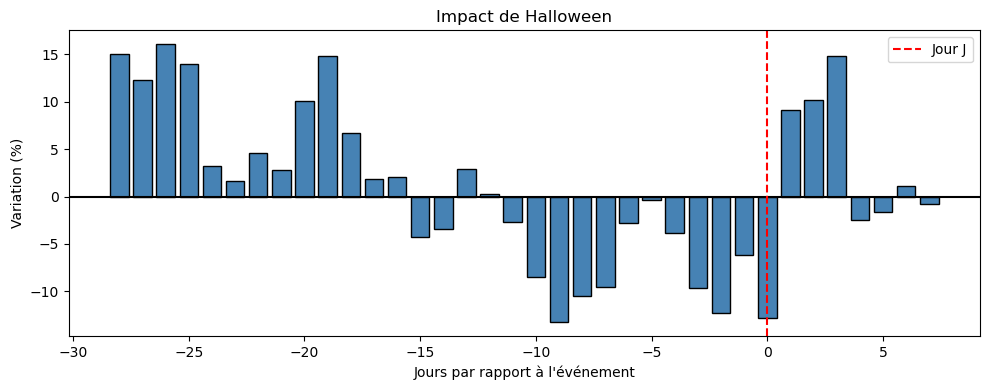

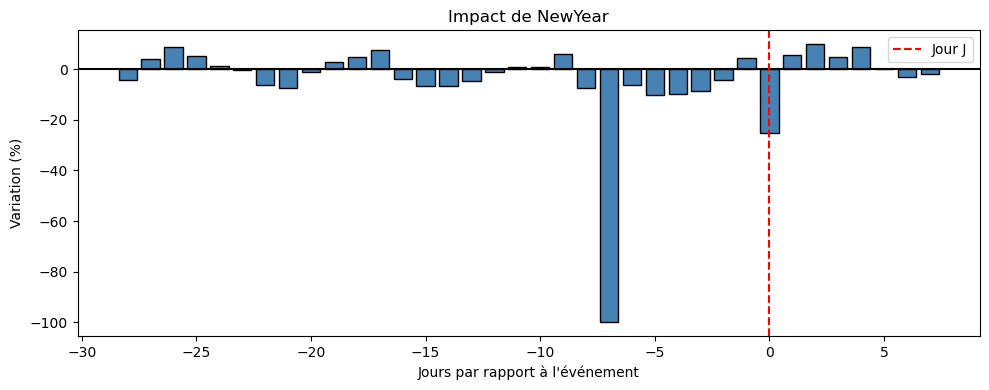

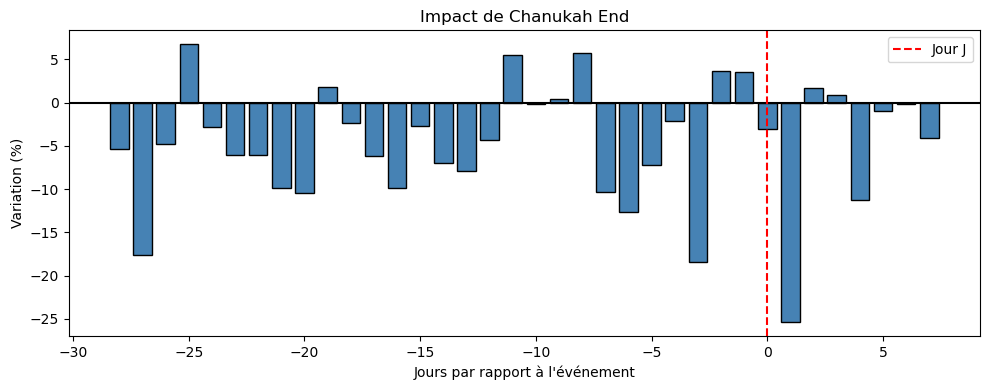

In [24]:
for event, data in resultats_globaux.items():

    offsets = data["offsets"]
    variations = data["variations"]

    plt.figure(figsize=(10,4))

    plt.bar(offsets, variations,
            color='steelblue',
            edgecolor='black')

    plt.axhline(0, color='black')
    
    plt.axvline(0,
                color='red',
                linestyle='--',
                label='Jour J')

    plt.title(f'Impact de {event}')
    plt.xlabel("Jours par rapport à l'événement")
    plt.ylabel("Variation (%)")

    plt.legend()

    plt.tight_layout()
    plt.show()

In [25]:
for event, data in resultats_globaux.items():

    print(event)
    print("Hausse max :", round(max(data["variations"]), 1), "%")
    print("Baisse max :", round(min(data["variations"]), 1), "%")
    print()

SuperBowl
Hausse max : 36.9 %
Baisse max : -21.3 %

ValentinesDay
Hausse max : 13.5 %
Baisse max : -7.9 %

PresidentsDay
Hausse max : 22.7 %
Baisse max : -17.6 %

LentStart
Hausse max : 23.7 %
Baisse max : -13.7 %

StPatricksDay
Hausse max : 9.2 %
Baisse max : -8.5 %

OrthodoxEaster
Hausse max : 20.0 %
Baisse max : -15.4 %

Cinco De Mayo
Hausse max : 14.3 %
Baisse max : -13.1 %

Mother's day
Hausse max : 26.2 %
Baisse max : -9.2 %

MemorialDay
Hausse max : 22.4 %
Baisse max : -21.8 %

NBAFinalsStart
Hausse max : 22.1 %
Baisse max : -19.2 %

NBAFinalsEnd
Hausse max : 7.4 %
Baisse max : -5.6 %

Father's day
Hausse max : 25.6 %
Baisse max : -16.2 %

IndependenceDay
Hausse max : 24.1 %
Baisse max : -7.6 %

LaborDay
Hausse max : 33.6 %
Baisse max : -14.5 %

ColumbusDay
Hausse max : 28.0 %
Baisse max : -11.3 %

VeteransDay
Hausse max : 11.3 %
Baisse max : -9.3 %

EidAlAdha
Hausse max : 6.4 %
Baisse max : -6.2 %

Eid al-Fitr
Hausse max : 8.9 %
Baisse max : -0.6 %

Ramadan starts
Hausse max : 

### 3.5 Interprétation des résultats

#### Événements à fort impact

Easter présente le plus fort pic positif avec environ **+40% à J-1**, probablement lié aux achats de dernière minute avant Pâques. SuperBowl suit avec une hausse d’environ **+35% à J-1**,ce qui est cohérent avec les achats alimentaires et festifs avant l’événement.

LaborDay montre une hausse étendue, avec des variations positives entre **J-2 et J+6**, traduisant l’effet du long week-end sur la consommation.

Thanksgiving présente plusieurs hausses avant l’événement (autour de **J-20, J-10 et J-5**), mais une forte baisse d’environ **-40% au jour J**, probablement due à une activité commerciale réduite.

Halloween est un évènement fortement anticipé avec des pics positifs entre **J-28 et J-25**, ce qui reflète les achats réalisés longtemps avant la fête.

Christmas affiche une chute proche de **-100% au jour J**, principalement expliquée par la fermeture des magasins le 25 décembre de Walmart.

#### Événements à impact moyen

Les jours fériés comme PresidentsDay, MartinLutherKingDay et ColumbusDay montrent des hausses modérées avant l’événement, souvent autour de **J-2**, avec des variations pouvant atteindre **+20% à +27%**.

Mother’s Day et Father’s Day présentent également des hausses avant l’événement, notamment vers **J-7**, liées aux achats de cadeaux.

IndependenceDay montre une augmentation proche de **+24% à J-1**, cohérente avec les achats pour les célébrations et barbecues.

#### Événements à faible impact

Les fêtes religieuses comme Eid al-Fitr, Ramadan ou OrthodoxChristmas présentent des variations plus faibles, généralement inférieures à **10%**, avec des effets moins réguliers.

Les fêtes juives montrent également des impacts plus limités, sans grande tendance.

Enfin, on interprète les variations négatives observées autour de NewYear avec vigilance, car elles sont probablement influencées par la proximité avec Christmas et les fermetures de fin d’année.

NB: je tiens à noter que les déductions que l'on fait peuvent être confirmées pour Christmas car effectivement le magasin ferme mais pour les autres, ce sont des hypothèses qui sonnent bien avec la réalité mais que l'on ne peut pas affirmer à 100% avec seulement les données. 

## 4. Impact des événements par magasin

L'analyse globale nous a permis d'identifier les événements les plus impactants. On descend maintenant à l'échelle du magasin pour vérifier si tous les magasins réagissent de la même façon ou si certains sont plus sensibles que d'autres. Ces résultats alimenteront directement notre partie Recherche Opérationnelle.

### 4.1 Fonction de calcul de l'impact par magasin

On réutilise la même logique que pour l'analyse globale mais cette fois on compare chaque magasin à sa propre moyenne et non à la baseline globale.

In [17]:
daily_by_store = {}
for store in sales["store_id"].unique():
    ventes_store = sales[sales["store_id"] == store][day_cols].sum()
    daily_by_store[store] = pd.Series(
        ventes_store.values,
        index=[day_to_date[d] for d in day_cols]
    ).sort_index()

def impact_event_magasin(store, nom_event, offsets):
    serie    = daily_by_store[store]
    baseline = serie.mean()
    dates    = calendar[calendar["event_name_1"] == nom_event]["date"].tolist()
    
    variations = []
    for offset in offsets:
        ventes = []
        for date in dates:
            date_cible = date + pd.Timedelta(days=offset)
            if date_cible in serie.index:
                ventes.append(serie[date_cible])
        if ventes:
            variations.append((np.mean(ventes) / baseline - 1) * 100)
        else:
            variations.append(0)
    return variations

### 4.2 Heatmap impact des 5 events clés par magasin

Pour chaque magasin et chaque event on calcule le pic d'impact maximum. Le vert indique une hausse des ventes, le rouge une baisse.

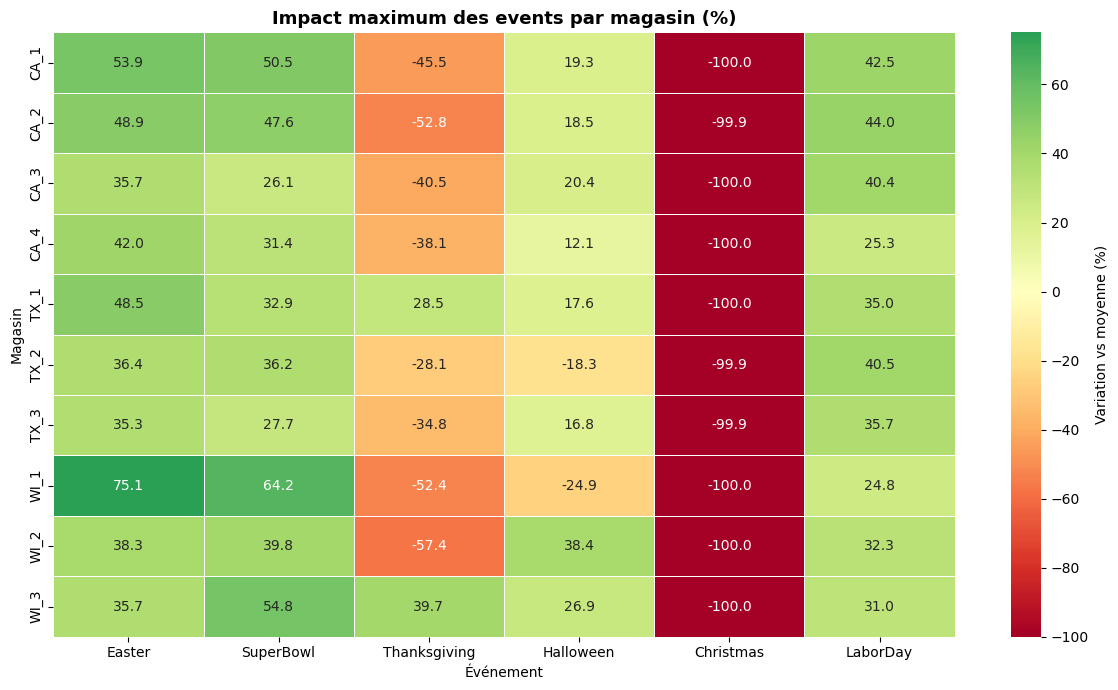

In [27]:
events_cles  = ["Easter", "SuperBowl", "Thanksgiving", "Halloween", "Christmas", "LaborDay"]
offsets_cles = {
    "Easter"      : list(range(-7, 8)),
    "SuperBowl"   : list(range(-7, 8)),
    "Thanksgiving": list(range(-28, 8)),
    "Halloween"   : list(range(-28, 8)),
    "Christmas"   : list(range(-28, 8)),
    "LaborDay"    : list(range(-28, 8)),
}

heatmap_data = pd.DataFrame(
    index=sorted(daily_by_store.keys()),
    columns=events_cles
)

for store in sorted(daily_by_store.keys()):
    for event in events_cles:
        offsets    = offsets_cles[event]
        variations = impact_event_magasin(store, event, offsets)
        idx_max    = np.argmax(np.abs(variations))
        heatmap_data.loc[store, event] = round(variations[idx_max], 1)

heatmap_data = heatmap_data.astype(float)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5,
            cbar_kws={"label": "Variation vs moyenne (%)"})
plt.title("Impact maximum des events par magasin (%)", fontsize=13, fontweight='bold')
plt.xlabel("Événement")
plt.ylabel("Magasin")
plt.tight_layout()
plt.show()

### Interprétation de la heatmap

**Christmas (-100% partout)**
Walmart ferme le 25 décembre dans tous les états. Seul event identique pour tous les magasins donc pas besoin d'adapter la stratégie : juste anticiper la fermeture et ne pas sur-stocker.

**Easter et SuperBowl (hausses significatives)**
WI_1 ressort clairement comme le magasin le plus réactif sur ces deux events (+75% Easter, +64% SuperBowl). CA_3 qui est le plus gros magasin en volume est le moins sensible, surprenant mais vrai.

**Thanksgiving (le plus compliqué)**
Les comportements sont opposés selon les magasins : WI_1 et WI_2 chutent (-52%, -57%) pendant que WI_3 et TX_1 sont positifs (+40%, +29%). Il n'est donc pas possible d'appliquer une règle uniforme, il faut regarder l'historique magasin par magasin. Donc pour notre application il est préférable de ne pas choisir cet event pour ne pas se compliquer encore plus la tâche. 

**Halloween et LaborDay (impacts modérés)**
Halloween est variable selon les magasins, WI_2 profite (+38%) tandis que que TX_2 et WI_1 sont légèrement négatifs. LaborDay est plus homogène avec des hausses entre +25% et +44% sur tous les magasins.

**Ce qu'on retient**
WI_1 est le magasin le plus sensible aux events malgré ses faibles ventes globales, CA_3 le moins sensible malgré son volume. Chaque magasin a son propre profil de réaction ce qui justifie l'utilisation de `store_id_enc` et `event_enc` ensemble dans le modèle, et des alertes différenciées par magasin dans le Streamlit.

**IMPORTANT** : Le dataset s'arrête en mai donc notre prédiction sera à cette période. De ce fait, pour des raisons de précision pour notre modélisation, choisir des events comme Noël, Thanksgiving, etc aurait été plus intéressant car fort impact. Mais nous allons plus afiiner notre recherche sur des events en mai-juin max afin de ne pas venir impacter la précision de nos prédictions et donc le forecasting. Néanmoins cela ne change en rien en la cohérence de l'analyse ici et les conseils d'actions à effectuer écrites ci-dessus en conseil à Sophie Martin. De plus, cette analyse nous sera utile pour la partie recherche opérationnelle. 

In [20]:
# Events qui tombent en mai et juin
events_mai_juin = calendar[
    (calendar['date'].dt.month.isin([5, 6])) & 
    (calendar['event_name_1'].notna())
][['date', 'event_name_1']].drop_duplicates('event_name_1')

print(events_mai_juin.to_string())

           date    event_name_1
96   2011-05-05   Cinco De Mayo
99   2011-05-08    Mother's day
121  2011-05-30     MemorialDay
122  2011-05-31  NBAFinalsStart
134  2011-06-12    NBAFinalsEnd
141  2011-06-19    Father's day
827  2013-05-05  OrthodoxEaster
1247 2014-06-29  Ramadan starts


### 4.3 Heatmap events majeurs vs events de mai/juin

On sépare les deux analyses pour plus de lisibilité : les 5 events majeurs d'abord, puis les events spécifiques à mai/juin qui sont pertinents pour notre prévision future. Nos données de ventes s'arrêtent le 2016-05-08 donc on gardera les deux events les plus intéressants pour la prévision. 

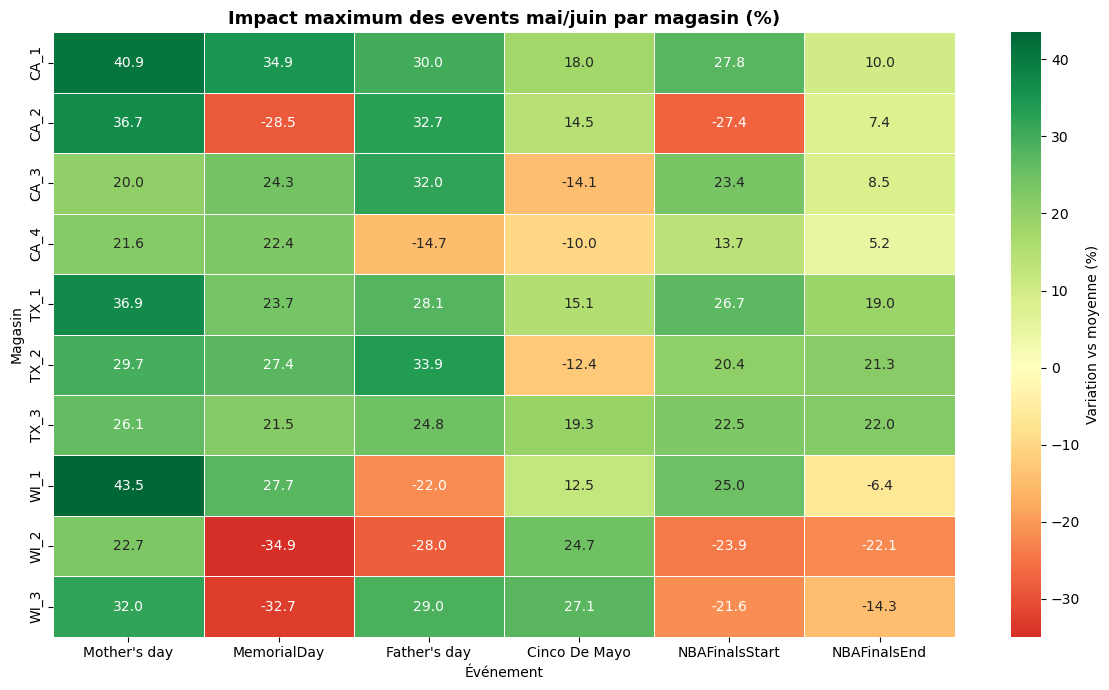

In [21]:
events_mai_juin  = ["Mother's day", "MemorialDay", "Father's day", 
                    "Cinco De Mayo", "NBAFinalsStart", "NBAFinalsEnd"]
offsets_mai_juin = {e: list(range(-7, 8)) for e in events_mai_juin}

heatmap_mai_juin = pd.DataFrame(index=sorted(daily_by_store.keys()), columns=events_mai_juin)

for store in sorted(daily_by_store.keys()):
    for event in events_mai_juin:
        variations = impact_event_magasin(store, event, offsets_mai_juin[event])
        idx_max    = np.argmax(np.abs(variations))
        heatmap_mai_juin.loc[store, event] = round(variations[idx_max], 1)

heatmap_mai_juin = heatmap_mai_juin.astype(float)

plt.figure(figsize=(12, 7))
sns.heatmap(heatmap_mai_juin, annot=True, fmt=".1f", cmap="RdYlGn",
            center=0, linewidths=0.5,
            cbar_kws={"label": "Variation vs moyenne (%)"})
plt.title("Impact maximum des events mai/juin par magasin (%)", fontsize=13, fontweight='bold')
plt.xlabel("Événement")
plt.ylabel("Magasin")
plt.tight_layout()
plt.show()

**Interprétation heatmap mai/juin :**

Mother's Day est l'event le plus homogène de la période avec des hausses positives sur tous 
les magasins. WI_1 est le plus réactif (+43.5%) et CA_3 le moins sensible (+20%). 
C'est cohérent avec ce qu'on observe sur les autres events : WI_1 réagit toujours plus. 

Memorial Day est l'event le plus compliqué. CA_1 monte à +35% pendant que WI_2 et WI_3 
chutent à -35% et -33%. Les magasins Wisconsin et Californie réagissent à l'opposé 
sur ce weekend prolongé, une stratégie uniforme serait une erreur.

Father's Day suit un pattern proche de Mother's Day avec des hausses générales sur presque 
tous les magasins. WI_2 fait exception avec -28%, à surveiller.

Cinco De Mayo a un impact légèrement plus marqué au Texas (+19% à +22%) ce qui fait 
sens à l'échelle géographique. Les magasins Californie témoignent d'une certaine modération. 

NBAFinalsStart et NBAFinalsEnd ont des impacts changeant. WI_2 chute sur les deux 
(-23.9% et -22.1%), WI_3 aussi. En revanche TX_3 profite des deux events (+22% et +22%).

**Choix des events pour Sophie Martin dans le Streamlit :**

Notre dataset de ventes s'arrête au 2016-05-08. On ne garde donc dans les alertes que 
les events qui tombent après cette date, c'est à dire ceux pour lesquels Sophie Martin 
a encore le temps d'agir :

- **Memorial Day (2016-05-30)**  
- **Father's Day (2016-06-19)** 

Mother's Day et Cinco De Mayo tombent avant ou au dernier jour du dataset, 
ils sont donc analysés ici et pour la RO mais pas intégrés dans les alertes futures.